

**Quy ước nhãn:** `0 = REAL (Tin thật)` | `1 = FAKE (Tin giả)`


## 1️⃣ Cài đặt thư viện

In [ ]:
!pip install -q kagglehub transformers torch pyvi scikit-learn

print("✅ Cài đặt hoàn tất!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.9 MB/s eta 0:00:00
✅ Cài đặt hoàn tất!


## 2️⃣ Cấu hình Kaggle API

In [ ]:

from google.colab import files
import os

print("📤 Upload file kaggle.json...")
uploaded = files.upload()

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
os.rename('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print("✅ Kaggle API đã được cấu hình!")


📤 Upload file kaggle.json...


Saving kaggle.json to kaggle.json
✅ Kaggle API đã được cấu hình!


 Tải & Gộp Dataset

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
import unicodedata
from pathlib import Path

DATA_DIR = Path('/content/data')
DATA_DIR.mkdir(parents=True, exist_ok=True)
MERGED_PATH = DATA_DIR / 'merged_datasets.csv'

print("📥 Đang tải 4 datasets từ Kaggle...")
df_list = []

# Dataset 1
try:
    path1 = kagglehub.dataset_download("phngnguynthu1803/vietnamese-fake-news-dataset")
    for file in sorted(os.listdir(path1)):
        if not file.endswith('.csv'): continue
        try:
            temp = pd.read_csv(os.path.join(path1, file), encoding='utf-8')
            temp.rename(columns={'news': 'text', 'content': 'text'}, inplace=True)
            if 'real' in file.lower():   temp['label'] = 0
            elif 'fake' in file.lower(): temp['label'] = 1
            else:
                print(f"   ⚠️ Bỏ qua '{file}' — không xác định nhãn")
                continue
            if 'text' in temp.columns:
                df_list.append(temp[['text', 'label']].dropna())
                print(f"   ✅ DS1/{file}: {len(temp):,} mẫu")
        except: pass
except Exception as e: print(f"❌ DS1: {e}")

# Dataset 2
try:
    path2 = kagglehub.dataset_download("chuynvinquc/fakenewvn")
    for fname in [f for f in os.listdir(path2) if f.endswith('.csv')]:
        temp = pd.read_csv(os.path.join(path2, fname), encoding='utf-8')
        temp.rename(columns={'post_message': 'text'}, inplace=True)
        if 'text' in temp.columns and 'label' in temp.columns:
            temp['label'] = pd.to_numeric(temp['label'], errors='coerce')
            temp.dropna(subset=['label'], inplace=True)
            temp['label'] = temp['label'].astype(int)
            df_list.append(temp[['text', 'label']])
            print(f"   ✅ DS2/{fname}: {len(temp):,} mẫu")
except Exception as e: print(f"❌ DS2: {e}")

# Dataset 3
try:
    path3 = kagglehub.dataset_download("goumanguyen/vietnamese-fake-news-dataset-pbl7")
    for root, _, files in os.walk(path3):
        for file in sorted(files):
            if not file.endswith('.csv'): continue
            try:
                temp = pd.read_csv(os.path.join(root, file), encoding='utf-8')
                temp.rename(columns={'Maintext':'text','maintext':'text','Label':'label'}, inplace=True)
                if 'text' in temp.columns and 'label' in temp.columns:
                    if temp['label'].dtype == object:
                        temp['label'] = temp['label'].map(
                            {'Real':0,'real':0,'Fake':1,'fake':1,'TIN THẬT':0,'TIN GIẢ':1})
                    temp['label'] = pd.to_numeric(temp['label'], errors='coerce')
                    temp.dropna(subset=['label','text'], inplace=True)
                    temp['label'] = temp['label'].astype(int)
                    df_list.append(temp[['text','label']])
                    print(f"   ✅ DS3/{file}: {len(temp):,} mẫu")
            except: pass
except Exception as e: print(f"❌ DS3: {e}")

# Dataset 4
try:
    path4 = kagglehub.dataset_download("leviettrieu369/vietnamese-medical-fake-news-dataset")
    for fname in [f for f in os.listdir(path4) if f.endswith('.csv')]:
        temp = pd.read_csv(os.path.join(path4, fname), encoding='utf-8')
        temp.rename(columns={'normalized_content':'text','is_fake':'label'}, inplace=True)
        if 'label' in temp.columns and 'text' in temp.columns:
            bool_map = {True:1,False:0,'True':1,'False':0,'TRUE':1,'FALSE':0,1:1,0:0}
            temp['label'] = temp['label'].map(bool_map)
            temp.dropna(subset=['label','text'], inplace=True)
            temp['label'] = temp['label'].astype(int)
            df_list.append(temp[['text','label']])
            print(f"   ✅ DS4/{fname}: {len(temp):,} mẫu")
except Exception as e: print(f"❌ DS4: {e}")

# Gộp & làm sạch
df_raw = pd.concat(df_list, ignore_index=True)
df_raw['text'] = df_raw['text'].apply(lambda x: unicodedata.normalize('NFC', str(x)))
df_raw.drop_duplicates(subset=['text'], keep='first', inplace=True)
df_raw = df_raw[df_raw['text'].str.len() >= 30]
df_raw = df_raw[df_raw['label'].isin([0, 1])]
df = df_raw.sample(frac=1, random_state=42).reset_index(drop=True)

df.to_csv(MERGED_PATH, index=False, encoding='utf-8-sig')
print(f"\n💾 Đã lưu: {MERGED_PATH}\n")

# ── Thống kê tổng quan ──
counts = df['label'].value_counts().sort_index()
print("\n" + "="*55)
print("📊 THỐNG KÊ DATASET CHUNG")
print("="*55)
print(f"  Tổng mẫu         : {len(df):,}")
print(f"  Tin thật (0)     : {counts.get(0,0):,}  ({counts.get(0,0)/len(df)*100:.1f}%)")
print(f"  Tin giả  (1)     : {counts.get(1,0):,}  ({counts.get(1,0)/len(df)*100:.1f}%)")
print("="*55)
print("✅ Dataset sẵn sàng cho cả 4 mô hình!")


📥 Đang tải 4 datasets từ Kaggle...


100%|██████████| 10.2M/10.2M [00:01<00:00, 9.61MB/s]

Extracting files...


   ✅ DS1/real_news.csv: 3,523 mẫu
   ✅ DS1/real_news_5500_balanced.csv: 4,175 mẫu


100%|██████████| 1.90M/1.90M [00:01<00:00, 1.47MB/s]

...

Extracting files...


   ✅ DS3/fix_test_data.csv: 161 mẫu
   ✅ DS3/update_train_data.csv: 849 mẫu
   ✅ DS3/update_val_data.csv: 171 mẫu
   ✅ DS3/fix_test_data.csv: 161 mẫu
   ✅ DS3/train_data.csv: 683 mẫu
   ✅ DS3/val_data.csv: 171 mẫu


100%|██████████| 20.6M/20.6M [00:02<00:00, 8.03MB/s]

Extracting files...


   ✅ DS4/full_dataset.csv: 10,617 mẫu

💾 Đã lưu: /content/data/merged_datasets.csv


📊 THỐNG KÊ DATASET CHUNG
  Tổng mẫu         : 22,054
  Tin thật (0)     : 15,886  (72.0%)
  Tin giả  (1)     : 6,168  (28.0%)
✅ Dataset sẵn sàng cho cả 4 mô hình!


THONG KE PHAN BO DATASET
  Tong mau     : 22,054
  Real (0)     : 15,886  (72.0%)
  Fake (1)     : 6,168  (28.0%)
  Nguon        : 4 datasets Kaggle (Tieng Viet)
  Loai mat CB  : TU NHIEN (gop nhieu nguon)


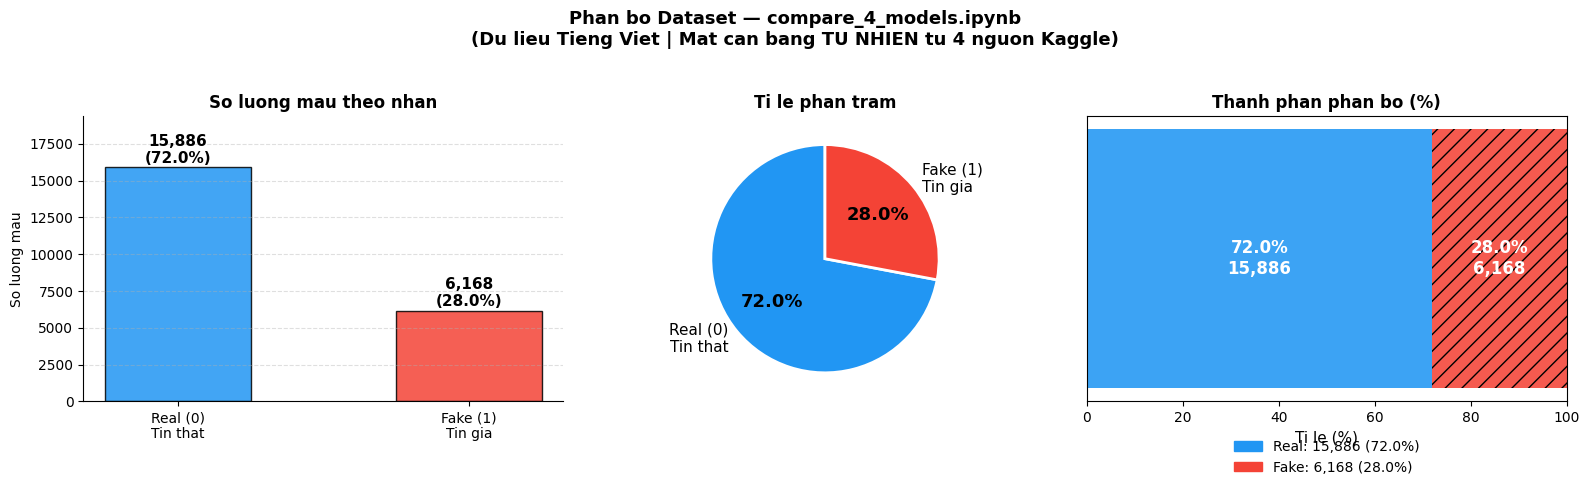

In [ ]:
# ==============================================================
# BIEU DO PHAN BO DATASET - compare_4_models.ipynb
# Nguon: 4 bo du lieu tieng Viet tu Kaggle (gop tu nhien)
# Nhan: 0 = Real (Tin that), 1 = Fake (Tin gia)
# ==============================================================
import matplotlib.pyplot as plt
import numpy as np

label_counts = df["label"].value_counts().sort_index()
real_count = int(label_counts.get(0, 0))
fake_count = int(label_counts.get(1, 0))
total      = real_count + fake_count
real_pct   = real_count / total * 100
fake_pct   = fake_count / total * 100

COLOR_REAL = "#2196F3"
COLOR_FAKE = "#F44336"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Phan bo Dataset — compare_4_models.ipynb\n"
    "(Du lieu Tieng Viet | Mat can bang TU NHIEN tu 4 nguon Kaggle)",
    fontsize=13, fontweight="bold", y=1.03
)

# --- 1. Bar chart ---
bars = axes[0].bar(
    ["Real (0)\nTin that", "Fake (1)\nTin gia"],
    [real_count, fake_count],
    color=[COLOR_REAL, COLOR_FAKE],
    edgecolor="black", alpha=0.85, width=0.5
)
for bar, val, pct in zip(bars, [real_count, fake_count], [real_pct, fake_pct]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{val:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )
axes[0].set_title("So luong mau theo nhan", fontsize=12, fontweight="bold")
axes[0].set_ylabel("So luong mau")
axes[0].set_ylim(0, max(real_count, fake_count) * 1.22)
axes[0].grid(axis="y", alpha=0.4, linestyle="--")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# --- 2. Pie chart ---
wedges, texts, autotexts = axes[1].pie(
    [real_count, fake_count],
    labels=["Real (0)\nTin that", "Fake (1)\nTin gia"],
    autopct="%1.1f%%",
    colors=[COLOR_REAL, COLOR_FAKE],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    pctdistance=0.60,
    textprops={"fontsize": 11}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight("bold")
axes[1].set_title("Ti le phan tram", fontsize=12, fontweight="bold")

# --- 3. Horizontal stacked bar ---
axes[2].barh([0], [real_pct], color=COLOR_REAL, alpha=0.88)
axes[2].barh([0], [fake_pct], left=[real_pct], color=COLOR_FAKE, alpha=0.88, hatch="//")
axes[2].set_xlim(0, 100)
axes[2].set_yticks([])
axes[2].set_xlabel("Ti le (%)", fontsize=11)
axes[2].set_title("Thanh phan phan bo (%)", fontsize=12, fontweight="bold")
axes[2].text(real_pct / 2, 0, f"{real_pct:.1f}%\n{real_count:,}",
             ha="center", va="center", fontsize=12, fontweight="bold", color="white")
axes[2].text(real_pct + fake_pct / 2, 0, f"{fake_pct:.1f}%\n{fake_count:,}",
             ha="center", va="center", fontsize=12, fontweight="bold", color="white")
from matplotlib.patches import Patch
axes[2].legend(
    handles=[Patch(color=COLOR_REAL, label=f"Real: {real_count:,} ({real_pct:.1f}%)"),
             Patch(color=COLOR_FAKE, label=f"Fake: {fake_count:,} ({fake_pct:.1f}%)", hatch="//")],
    loc="lower center", bbox_to_anchor=(0.5, -0.30), fontsize=10, frameon=False
)

print("=" * 55)
print("THONG KE PHAN BO DATASET")
print(f"  Tong mau     : {total:,}")
print(f"  Real (0)     : {real_count:,}  ({real_pct:.1f}%)")
print(f"  Fake (1)     : {fake_count:,}  ({fake_pct:.1f}%)")
print(f"  Nguon        : 4 datasets Kaggle (Tieng Viet)")
print(f"  Loai mat CB  : TU NHIEN (gop nhieu nguon)")
print("=" * 55)

plt.tight_layout()
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Tiền xử lý & Chia tập dữ liệu



In [ ]:
import re
import string
import unicodedata
from pyvi import ViTokenizer
from sklearn.model_selection import train_test_split
import numpy as np

print("="*55)
print("🔤 TIỀN XỬ LÝ VĂN BẢN TIẾNG VIỆT (PHIÊN BẢN SỬA)")
print("="*55)

# ── [FIX #1] Danh sách Vietnamese Stopwords ──
# Loại bỏ các từ xuất hiện quá phổ biến, không mang ý nghĩa phân loại tin giả/thật
VIETNAMESE_STOPWORDS = set([
    # Giới từ / liên từ
    'và', 'của', 'là', 'cho', 'với', 'trong', 'từ', 'để', 'theo',
    'tại', 'về', 'trên', 'dưới', 'giữa', 'qua', 'bằng', 'vào',
    'ra', 'lên', 'xuống',
    # Đại từ
    'tôi', 'bạn', 'anh', 'chị', 'họ', 'chúng', 'nó', 'mình',
    'ta', 'em', 'ông', 'bà',
    # Trợ từ / phó từ
    'được', 'có', 'không', 'đã', 'đang', 'sẽ', 'cũng', 'còn',
    'lại', 'rất', 'nhiều', 'ít', 'thì', 'mà', 'nếu', 'nhưng',
    'hoặc', 'hay', 'vì', 'bởi', 'do', 'nên', 'mới', 'vẫn',
    'chỉ', 'đều', 'rồi', 'thật', 'quá',
    # Chỉ định / nghi vấn
    'này', 'đó', 'kia', 'nào', 'gì', 'sao', 'ai', 'đâu',
    'bao', 'mấy',
    # Từ chức năng khác
    'một', 'các', 'những', 'mỗi', 'mọi', 'cái', 'con', 'người',
    'việc', 'điều', 'cách', 'lúc', 'khi', 'nơi', 'chỗ',
    'thế', 'vậy', 'như', 'rằng', 'là', 'bị', 'hơn', 'nhất',
    'tất', 'cả', 'hết', 'luôn', 'ngay', 'thêm', 'nữa',
    'sau', 'trước', 'đến', 'lại', 'đi', 'về', 'đây',
])

print(f"📝 Số lượng stopwords: {len(VIETNAMESE_STOPWORDS)} từ")

def clean_text(text: str) -> str:
    """
    Làm sạch văn bản — dùng cho RF và SVM (TF-IDF).
    [FIX] Đã thêm bước loại bỏ stopwords tiếng Việt.
    """
    text = unicodedata.normalize('NFC', str(text)).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # [FIX #1] Loại bỏ stopwords tiếng Việt
    words = text.split()
    words = [w for w in words if w not in VIETNAMESE_STOPWORDS]
    return ' '.join(words)

def clean_and_segment(text: str) -> str:
    """
    Làm sạch + tách từ tiếng Việt — dùng cho LSTM và PhoBERT.
    ViTokenizer: 'học sinh' → 'học_sinh'
    """
    text = clean_text(text)
    return ViTokenizer.tokenize(text)

# Áp dụng cả 2 dạng tiền xử lý
print("⏳ Đang xử lý văn bản (có thể mất vài phút)...")
df['text_clean']    = df['text'].apply(clean_text)          # cho RF, SVM
df['text_segmented'] = df['text'].apply(clean_and_segment)  # cho LSTM, PhoBERT

# Loại dòng rỗng sau xử lý
df = df[df['text_clean'].str.len() > 5].reset_index(drop=True)
print(f"✅ Còn lại: {len(df):,} mẫu sau tiền xử lý")

# ── [FIX #5] Chia Train / Val / Test bằng INDEX CHUNG ──
# Đảm bảo X_raw và X_seg luôn khớp index chính xác
X_raw  = df['text_clean'].values
X_seg  = df['text_segmented'].values
y      = df['label'].values
indices = np.arange(len(y))

# Bước 1: Tách test (15%)
idx_temp, idx_test, y_temp, y_test = train_test_split(
    indices, y, test_size=0.15, random_state=42, stratify=y)

# Bước 2: Tách val từ phần còn lại (0.176 ≈ 15% tổng)
idx_train, idx_val, y_train, y_val = train_test_split(
    idx_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

# Áp dụng index chung cho cả X_raw và X_seg
X_raw_train, X_raw_val, X_raw_test = X_raw[idx_train], X_raw[idx_val], X_raw[idx_test]
X_seg_train, X_seg_val, X_seg_test = X_seg[idx_train], X_seg[idx_val], X_seg[idx_test]

total = len(y)
print("\n✂️  CHIA TẬP (70% Train | 15% Val | 15% Test) — Dùng INDEX CHUNG")
print(f"   Train : {len(y_train):,} mẫu ({len(y_train)/total*100:.1f}%)")
print(f"   Val   : {len(y_val):,} mẫu ({len(y_val)/total*100:.1f}%)")
print(f"   Test  : {len(y_test):,} mẫu ({len(y_test)/total*100:.1f}%)")
print("\n✅ Tất cả 4 mô hình sẽ dùng chung cách chia này!")


🔤 TIỀN XỬ LÝ VĂN BẢN TIẾNG VIỆT (PHIÊN BẢN SỬA)
📝 Số lượng stopwords: 105 từ
⏳ Đang xử lý văn bản (có thể mất vài phút)...
✅ Còn lại: 22,054 mẫu sau tiền xử lý

✂️  CHIA TẬP (70% Train | 15% Val | 15% Test) — Dùng INDEX CHUNG
   Train : 15,445 mẫu (70.0%)
   Val   : 3,300 mẫu (15.0%)
   Test  : 3,309 mẫu (15.0%)

✅ Tất cả 4 mô hình sẽ dùng chung cách chia này!


## Vectorization — TF-IDF (cho Random Forest & SVM)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

print("="*55)
print("📐 TF-IDF VECTORIZATION")
print("="*55)
print("""
TF-IDF chuyển văn bản → vector số:
  TF  = tần suất từ trong văn bản
  IDF = độ hiếm của từ trong toàn bộ corpus
  → Từ quan trọng & hiếm sẽ có trọng số cao hơn
""")

# TF-IDF với n-gram (1,2) để bắt thêm cụm 2 từ
# sublinear_tf=True: dùng log(tf) thay vì tf thô
tfidf = TfidfVectorizer(
    max_features=50000,    # Giữ 50k từ phổ biến nhất
    ngram_range=(1, 2),    # Unigram + Bigram
    sublinear_tf=True,     # log(1+tf) — giảm ảnh hưởng từ lặp nhiều
    min_df=2,              # Bỏ từ xuất hiện < 2 lần
    analyzer='word'
)

# Chỉ fit trên tập train — tránh data leakage
X_tfidf_train = tfidf.fit_transform(X_raw_train)
X_tfidf_val   = tfidf.transform(X_raw_val)
X_tfidf_test  = tfidf.transform(X_raw_test)

print(f"✅ TF-IDF Matrix:")
print(f"   Vocab size : {len(tfidf.vocabulary_):,} features")
print(f"   Train shape: {X_tfidf_train.shape}")
print(f"   Val shape  : {X_tfidf_val.shape}")
print(f"   Test shape : {X_tfidf_test.shape}")
print(f"   Sparsity   : {1 - X_tfidf_train.nnz / (X_tfidf_train.shape[0]*X_tfidf_train.shape[1]):.4f}")


📐 TF-IDF VECTORIZATION

TF-IDF chuyển văn bản → vector số:
  TF  = tần suất từ trong văn bản
  IDF = độ hiếm của từ trong toàn bộ corpus
  → Từ quan trọng & hiếm sẽ có trọng số cao hơn

✅ TF-IDF Matrix:
   Vocab size : 50,000 features
   Train shape: (15445, 50000)
   Val shape  : (3300, 50000)
   Test shape : (3309, 50000)
   Sparsity   : 0.9935


Mô hình 1 — Random Forest

Thêm `max_depth=50` và `min_samples_leaf=4` để giảm overfitting.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
import time

print("="*55)
print("🌲 RANDOM FOREST (PHIÊN BẢN SỬA)")
print("="*55)
print("""
Random Forest = tập hợp nhiều cây quyết định (Decision Tree).
Mỗi cây được train trên subset ngẫu nhiên của dữ liệu.
Kết quả cuối = vote đa số từ tất cả cây.
Ưu điểm: Ít overfit, dễ giải thích, nhanh.
""")

# ── Khởi tạo và train ──
print("⏳ Đang train Random Forest...")
t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators=300,       # [FIX #2] Tăng từ 200 lên 300 cây
    max_depth=50,           # [FIX #2] Giới hạn độ sâu (trước đó: None)
    min_samples_split=10,   # [FIX #2] Tăng từ 5 lên 10
    min_samples_leaf=4,     # [FIX #2] Thêm: mỗi lá ít nhất 4 mẫu
    class_weight='balanced',# Tự động cân bằng nhãn mất cân bằng
    random_state=42,
    n_jobs=-1               # Dùng tất cả CPU core
)

rf_model.fit(X_tfidf_train, y_train)
rf_train_time = time.time() - t0
print(f"✅ Train xong trong {rf_train_time:.1f}s")

# ── Đánh giá ──
rf_preds_val  = rf_model.predict(X_tfidf_val)
rf_preds_test = rf_model.predict(X_tfidf_test)

rf_val_acc  = accuracy_score(y_val,  rf_preds_val)
rf_val_f1   = f1_score(y_val,  rf_preds_val,  average='macro')
rf_test_acc = accuracy_score(y_test, rf_preds_test)
rf_test_f1  = f1_score(y_test, rf_preds_test, average='macro')

print(f"\n📊 KẾT QUẢ RANDOM FOREST:")
print(f"   Val  Accuracy : {rf_val_acc:.4f}  |  Val  F1: {rf_val_f1:.4f}")
print(f"   Test Accuracy : {rf_test_acc:.4f}  |  Test F1: {rf_test_f1:.4f}")
print(f"\n📋 Classification Report (Test Set):")
print(classification_report(y_test, rf_preds_test,
      target_names=['REAL (0)', 'FAKE (1)'], digits=4))

# ── Top features quan trọng nhất ──
feature_names = tfidf.get_feature_names_out()
importances   = rf_model.feature_importances_
top_idx       = importances.argsort()[-15:][::-1]
print("🔑 Top 15 từ quan trọng nhất (Random Forest):")
for i, idx in enumerate(top_idx):
    print(f"   {i+1:2d}. '{feature_names[idx]}' ({importances[idx]:.4f})")


🌲 RANDOM FOREST (PHIÊN BẢN SỬA)

Random Forest = tập hợp nhiều cây quyết định (Decision Tree).
Mỗi cây được train trên subset ngẫu nhiên của dữ liệu.
Kết quả cuối = vote đa số từ tất cả cây.
Ưu điểm: Ít overfit, dễ giải thích, nhanh.

⏳ Đang train Random Forest...
✅ Train xong trong 45.2s

📊 KẾT QUẢ RANDOM FOREST:
   Val  Accuracy : 0.9055  |  Val  F1: 0.8770
   Test Accuracy : 0.9096  |  Test F1: 0.8830

📋 Classification Report (Test Set):
              precision    recall  f1-score   support

    REAL (0)     0.9162    0.9627    0.9388      2384
    FAKE (1)     0.8893    0.7730    0.8271       925

    accuracy                         0.9096      3309
   macro avg     0.9027    0.8678    0.8830      3309
weighted avg     0.9087    0.9096    0.9076      3309

🔑 Top 15 từ quan trọng nhất (Random Forest):
    1. 'thể' (0.0091)
    2. 'bệnh' (0.0090)
    3. 'phương nam' (0.0056)
    4. 'uống' (0.0055)
    5. 'cơ thể' (0.0055)
    6. 'covid' (0.0053)
    7. 'đau' (0.0046)
    8. 'năm' (0

## Mô hình 2 — SVM (Support Vector Machine)


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, accuracy_score, f1_score
import time

print("="*55)
print("📏 SVM (Support Vector Machine)")
print("="*55)
print("""
SVM tìm siêu phẳng (hyperplane) tối ưu để phân tách 2 lớp.
LinearSVC phù hợp với dữ liệu TF-IDF chiều cao (sparse).
Ưu điểm: Hiệu quả cao với văn bản, ít hyperparameter.
""")

print("⏳ Đang train SVM...")
t0 = time.time()

# LinearSVC nhanh hơn SVC kernel RBF với dữ liệu text chiều cao
# CalibratedClassifierCV để lấy xác suất (predict_proba)
svm_base = LinearSVC(
    C=1.0,               # Hệ số regularization
    max_iter=2000,       # Tăng lên nếu báo ConvergenceWarning
    class_weight='balanced',
    random_state=42
)
svm_model = CalibratedClassifierCV(svm_base, cv=3)
svm_model.fit(X_tfidf_train, y_train)
svm_train_time = time.time() - t0
print(f"✅ Train xong trong {svm_train_time:.1f}s")

# ── Đánh giá ──
svm_preds_val  = svm_model.predict(X_tfidf_val)
svm_preds_test = svm_model.predict(X_tfidf_test)

svm_val_acc  = accuracy_score(y_val,  svm_preds_val)
svm_val_f1   = f1_score(y_val,  svm_preds_val,  average='macro')
svm_test_acc = accuracy_score(y_test, svm_preds_test)
svm_test_f1  = f1_score(y_test, svm_preds_test, average='macro')

print(f"\n📊 KẾT QUẢ SVM:")
print(f"   Val  Accuracy : {svm_val_acc:.4f}  |  Val  F1: {svm_val_f1:.4f}")
print(f"   Test Accuracy : {svm_test_acc:.4f}  |  Test F1: {svm_test_f1:.4f}")
print(f"\n📋 Classification Report (Test Set):")
print(classification_report(y_test, svm_preds_test,
      target_names=['REAL (0)', 'FAKE (1)'], digits=4))


📏 SVM (Support Vector Machine)

SVM tìm siêu phẳng (hyperplane) tối ưu để phân tách 2 lớp.
LinearSVC phù hợp với dữ liệu TF-IDF chiều cao (sparse).
Ưu điểm: Hiệu quả cao với văn bản, ít hyperparameter.

⏳ Đang train SVM...
✅ Train xong trong 1.3s

📊 KẾT QUẢ SVM:
   Val  Accuracy : 0.9364  |  Val  F1: 0.9195
   Test Accuracy : 0.9450  |  Test F1: 0.9307

📋 Classification Report (Test Set):
              precision    recall  f1-score   support

    REAL (0)     0.9535    0.9711    0.9622      2384
    FAKE (1)     0.9217    0.8778    0.8992       925

    accuracy                         0.9450      3309
   macro avg     0.9376    0.9244    0.9307      3309
weighted avg     0.9446    0.9450    0.9446      3309



Mô hình 3 — LSTM

1. ✅ Thêm **class_weight** trong CrossEntropyLoss
2. ✅ Thêm **EarlyStopping** (patience=3)
3. ✅ Thêm **ReduceLROnPlateau** scheduler
4. ✅ Tăng epochs lên 15, giảm LR xuống 5e-4

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.metrics import classification_report, accuracy_score, f1_score
from collections import Counter
import time
import numpy as np

print("="*55)
print("🔁 LSTM (Long Short-Term Memory) — PHIÊN BẢN SỬA")
print("="*55)
print("""
LSTM là mạng nơ-ron hồi quy (RNN) có khả năng ghi nhớ
ngữ cảnh dài hạn trong câu.
Ưu điểm so với RF/SVM: Hiểu thứ tự từ và ngữ cảnh.
Nhược điểm so với PhoBERT: Không có pretrained weights.

[FIX] Đã thêm: class_weight, EarlyStopping, LR Scheduler
""")

# ── CONFIG ──
VOCAB_SIZE  = 30000   # Giữ 30k từ phổ biến nhất
EMBED_DIM   = 128     # Kích thước embedding
HIDDEN_DIM  = 256     # Kích thước hidden state LSTM
NUM_LAYERS  = 2       # Số lớp LSTM chồng nhau
DROPOUT     = 0.3     # Dropout để tránh overfit
MAX_SEQ_LEN = 200     # Độ dài tối đa chuỗi token
BATCH_SIZE  = 64
EPOCHS_LSTM = 15      # [FIX #3] Tăng từ 5 lên 15 (có EarlyStopping bảo vệ)
LR_LSTM     = 5e-4    # [FIX #3] Giảm từ 1e-3 xuống 5e-4
PATIENCE    = 3       # [FIX #3] EarlyStopping patience

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️  Thiết bị: {device}")

# ── Xây dựng từ điển (Vocabulary) ──
print("\n⏳ Đang xây dựng từ điển...")
all_words = []
for text in X_seg_train:
    all_words.extend(text.split())

word_freq  = Counter(all_words)
vocab      = ['<PAD>', '<UNK>'] + [w for w, f in word_freq.most_common(VOCAB_SIZE - 2)]
word2idx   = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
print(f"✅ Từ điển: {VOCAB_SIZE:,} từ")

def text_to_ids(text, max_len=MAX_SEQ_LEN):
    """Chuyển văn bản → danh sách index, padding/truncate đến max_len."""
    ids = [word2idx.get(w, 1) for w in text.split()]  # 1 = <UNK>
    if len(ids) < max_len:
        ids = ids + [0] * (max_len - len(ids))         # 0 = <PAD>
    return ids[:max_len]

# ── Dataset class ──
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.X = [text_to_ids(t) for t in texts]
        self.y = labels

    def __len__(self): return len(self.y)

    def __getitem__(self, i):
        return (torch.tensor(self.X[i], dtype=torch.long),
                torch.tensor(self.y[i], dtype=torch.long))

train_dl = DataLoader(TextDataset(X_seg_train, y_train),
                      batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(TextDataset(X_seg_val,   y_val),
                      batch_size=BATCH_SIZE)
test_dl  = DataLoader(TextDataset(X_seg_test,  y_test),
                      batch_size=BATCH_SIZE)

# ── Kiến trúc LSTM ──
class LSTMClassifier(nn.Module):
    """
    Mô hình LSTM 2 chiều (Bidirectional) cho phân loại văn bản.
    Embedding → BiLSTM → Dropout → Linear → Output (2 nhãn)
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        # Embedding layer: chuyển index → vector
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Bidirectional LSTM: đọc chuỗi từ 2 chiều → hiểu ngữ cảnh tốt hơn
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,   # Forward + Backward
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        # hidden_dim * 2 vì bidirectional
        self.fc = nn.Linear(hidden_dim * 2, 2)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, _) = self.lstm(embedded)
        # Lấy hidden state của layer cuối (forward + backward)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden))

lstm_model = LSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM,
                              NUM_LAYERS, DROPOUT).to(device)
optimizer_lstm = Adam(lstm_model.parameters(), lr=LR_LSTM)

# [FIX #3] Thêm class_weight vào CrossEntropyLoss
class_counts = np.bincount(y_train)
class_weights_tensor = torch.tensor(
    [len(y_train) / (2.0 * c) for c in class_counts],
    dtype=torch.float
).to(device)
print(f"⚖️  Class weights (LSTM): Real={class_weights_tensor[0]:.3f}, Fake={class_weights_tensor[1]:.3f}")
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# [FIX #3] Thêm Learning Rate Scheduler
scheduler_lstm = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lstm, mode='max', factor=0.5, patience=2
)

total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"✅ LSTM model: {total_params:,} tham số")

# ── Training loop ──
lstm_history = {'train_acc': [], 'val_acc': [], 'val_f1': []}
best_lstm_f1   = 0.0
best_lstm_path = '/content/data/lstm_best.pt'
no_improve = 0  # [FIX #3] EarlyStopping counter

print(f"\n🚀 Bắt đầu training LSTM ({EPOCHS_LSTM} epochs, EarlyStopping patience={PATIENCE})...")

for epoch in range(1, EPOCHS_LSTM + 1):
    t0 = time.time()

    # Train
    lstm_model.train()
    correct, total_n, total_loss = 0, 0, 0.0
    for X_batch, y_batch in train_dl:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_lstm.zero_grad()
        logits = lstm_model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        optimizer_lstm.step()
        preds    = torch.argmax(logits, dim=1)
        correct += (preds == y_batch).sum().item()
        total_n += y_batch.size(0)
        total_loss += loss.item()
    train_acc = correct / total_n

    # Validate
    lstm_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_dl:
            preds = torch.argmax(lstm_model(X_batch.to(device)), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1  = f1_score(all_labels, all_preds, average='macro')

    lstm_history['train_acc'].append(train_acc)
    lstm_history['val_acc'].append(val_acc)
    lstm_history['val_f1'].append(val_f1)

    # [FIX #3] LR Scheduler step
    scheduler_lstm.step(val_f1)

    elapsed = time.time() - t0
    saved   = ''
    if val_f1 > best_lstm_f1:
        best_lstm_f1 = val_f1
        torch.save(lstm_model.state_dict(), best_lstm_path)
        saved = ' 💾 Best saved!'
        no_improve = 0  # Reset counter
    else:
        no_improve += 1  # [FIX #3] EarlyStopping

    current_lr = optimizer_lstm.param_groups[0]['lr']
    print(f"  Epoch {epoch}/{EPOCHS_LSTM} | {elapsed:.0f}s | "
          f"Loss={total_loss/len(train_dl):.4f} | "
          f"TrainAcc={train_acc:.4f} | ValAcc={val_acc:.4f} | "
          f"ValF1={val_f1:.4f} | LR={current_lr:.1e}{saved}")

    # [FIX #3] EarlyStopping check
    if no_improve >= PATIENCE:
        print(f"\n⛔ EarlyStopping triggered! Không cải thiện sau {PATIENCE} epochs.")
        break

# ── Đánh giá trên Test ──
lstm_model.load_state_dict(torch.load(best_lstm_path))
lstm_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_dl:
        preds = torch.argmax(lstm_model(X_batch.to(device)), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

lstm_test_acc = accuracy_score(all_labels, all_preds)
lstm_test_f1  = f1_score(all_labels, all_preds, average='macro')
lstm_preds_test = all_preds

print(f"\n📊 KẾT QUẢ LSTM (Test Set):")
print(f"   Test Accuracy : {lstm_test_acc:.4f}")
print(f"   Test F1 (macro): {lstm_test_f1:.4f}")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, lstm_preds_test,
      target_names=['REAL (0)', 'FAKE (1)'], digits=4))

🔁 LSTM (Long Short-Term Memory) — PHIÊN BẢN SỬA

LSTM là mạng nơ-ron hồi quy (RNN) có khả năng ghi nhớ
ngữ cảnh dài hạn trong câu.
Ưu điểm so với RF/SVM: Hiểu thứ tự từ và ngữ cảnh.
Nhược điểm so với PhoBERT: Không có pretrained weights.

[FIX] Đã thêm: class_weight, EarlyStopping, LR Scheduler


🖥️  Thiết bị: cuda

⏳ Đang xây dựng từ điển...
✅ Từ điển: 30,000 từ
⚖️  Class weights (LSTM): Real=0.694, Fake=1.788
✅ LSTM model: 6,208,514 tham số

🚀 Bắt đầu training LSTM (15 epochs, EarlyStopping patience=3)...
  Epoch 1/15 | 21s | Loss=0.5708 | TrainAcc=0.6972 | ValAcc=0.8258 | ValF1=0.7811 | LR=5.0e-04 💾 Best saved!
  Epoch 2/15 | 21s | Loss=0.4332 | TrainAcc=0.8184 | ValAcc=0.8236 | ValF1=0.7887 | LR=5.0e-04 💾 Best saved!
  Epoch 3/15 | 22s | Loss=0.3759 | TrainAcc=0.8538 | ValAcc=0.8576 | ValF1=0.8151 | LR=5.0e-04 💾 Best saved!
  Epoch 4/15 | 25s | Loss=0.3164 | TrainAcc=0.8745 | ValAcc=0.8733 | ValF1=0.8334 | LR=5.0e-04 💾 Best saved!
  Epoch 5/15 | 24s | Loss=0.2815 | TrainAcc=0.8945 

Mô hình 4 — PhoBERT


1. ✅ Thêm **class_weight** trong CrossEntropyLoss
2. ✅ Tăng epochs lên 5
3. ✅ Thêm **EarlyStopping** (patience=2)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, accuracy_score, f1_score
import time

print("="*55)
print("🤗 PHOBERT (VinAI) — PHIÊN BẢN SỬA")
print("="*55)
print("""
PhoBERT = BERT được pre-train trên 20GB văn bản tiếng Việt.
Hiểu sâu ngữ nghĩa, ngữ cảnh 2 chiều.
Thường đạt accuracy cao nhất trong 4 mô hình.

[FIX] Đã thêm: class_weight trong loss, EarlyStopping, tăng epochs
""")

PHOBERT_NAME  = "vinai/phobert-base"
MAX_LEN_BERT  = 256
BATCH_BERT    = 16
EPOCHS_BERT   = 5     # [FIX #4] Tăng từ 3 lên 5 (có EarlyStopping bảo vệ)
LR_BERT       = 2e-5
PATIENCE_BERT = 2     # [FIX #4] EarlyStopping patience

# ── Dataset ──
class BertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_len = tokenizer, max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, i):
        enc = self.tokenizer(
            str(self.texts[i]),
            max_length=self.max_len, padding='max_length',
            truncation=True, return_attention_mask=True,
            return_token_type_ids=False, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'labels': torch.tensor(int(self.labels[i]), dtype=torch.long)
        }

tokenizer_bert = AutoTokenizer.from_pretrained(PHOBERT_NAME)

train_bert = DataLoader(BertDataset(X_seg_train, y_train, tokenizer_bert, MAX_LEN_BERT),
                        batch_size=BATCH_BERT, shuffle=True, num_workers=2, pin_memory=True)
val_bert   = DataLoader(BertDataset(X_seg_val,   y_val,   tokenizer_bert, MAX_LEN_BERT),
                        batch_size=BATCH_BERT, num_workers=2, pin_memory=True)
test_bert  = DataLoader(BertDataset(X_seg_test,  y_test,  tokenizer_bert, MAX_LEN_BERT),
                        batch_size=BATCH_BERT, num_workers=2, pin_memory=True)

# ── Model & Optimizer ──
bert_model = AutoModelForSequenceClassification.from_pretrained(
    PHOBERT_NAME, num_labels=2).to(device)
optimizer_bert = AdamW(bert_model.parameters(), lr=LR_BERT, weight_decay=0.01)

total_steps  = len(train_bert) * EPOCHS_BERT
scheduler_bert = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

# [FIX #4] Thêm class_weight cho loss function
bert_class_weights = torch.tensor(
    [len(y_train) / (2.0 * c) for c in np.bincount(y_train)],
    dtype=torch.float
).to(device)
bert_loss_fn = nn.CrossEntropyLoss(weight=bert_class_weights)
print(f"⚖️  Class weights (PhoBERT): Real={bert_class_weights[0]:.3f}, Fake={bert_class_weights[1]:.3f}")

bert_history  = {'train_acc': [], 'val_acc': [], 'val_f1': []}
best_bert_f1  = 0.0
BERT_SAVE_PATH = '/content/data/phobert_best_model'
no_improve_bert = 0  # [FIX #4] EarlyStopping counter

print(f"\n🚀 Bắt đầu training PhoBERT ({EPOCHS_BERT} epochs, EarlyStopping patience={PATIENCE_BERT})...")

for epoch in range(1, EPOCHS_BERT + 1):
    t0 = time.time()

    # Train
    bert_model.train()
    correct, total_n, total_loss = 0, 0, 0.0
    for batch in train_bert:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labs = batch['labels'].to(device)
        optimizer_bert.zero_grad()
        # [FIX #4] Dùng custom loss thay vì loss mặc định của HuggingFace
        out  = bert_model(input_ids=ids, attention_mask=mask)
        loss = bert_loss_fn(out.logits, labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer_bert.step()
        scheduler_bert.step()
        preds    = torch.argmax(out.logits, dim=1)
        correct += (preds == labs).sum().item()
        total_n += labs.size(0)
        total_loss += loss.item()
    train_acc = correct / total_n

    # Validate
    bert_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_bert:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            preds = torch.argmax(
                bert_model(input_ids=ids, attention_mask=mask).logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['labels'].numpy())
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1  = f1_score(all_labels, all_preds, average='macro')

    bert_history['train_acc'].append(train_acc)
    bert_history['val_acc'].append(val_acc)
    bert_history['val_f1'].append(val_f1)

    elapsed = time.time() - t0
    saved   = ''
    if val_f1 > best_bert_f1:
        best_bert_f1 = val_f1
        bert_model.save_pretrained(BERT_SAVE_PATH)
        tokenizer_bert.save_pretrained(BERT_SAVE_PATH)
        saved = ' 💾 Best saved!'
        no_improve_bert = 0
    else:
        no_improve_bert += 1  # [FIX #4] EarlyStopping

    print(f"  Epoch {epoch}/{EPOCHS_BERT} | {elapsed:.0f}s | "
          f"Loss={total_loss/len(train_bert):.4f} | "
          f"TrainAcc={train_acc:.4f} | ValAcc={val_acc:.4f} | "
          f"ValF1={val_f1:.4f}{saved}")

    # [FIX #4] EarlyStopping check
    if no_improve_bert >= PATIENCE_BERT:
        print(f"\n⛔ EarlyStopping triggered! Không cải thiện sau {PATIENCE_BERT} epochs.")
        break

# ── Đánh giá trên Test ──
best_bert = AutoModelForSequenceClassification.from_pretrained(BERT_SAVE_PATH).to(device)
best_bert.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_bert:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        preds = torch.argmax(
            best_bert(input_ids=ids, attention_mask=mask).logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

bert_test_acc  = accuracy_score(all_labels, all_preds)
bert_test_f1   = f1_score(all_labels, all_preds, average='macro')
bert_preds_test = all_preds

print(f"\n📊 KẾT QUẢ PHOBERT (Test Set):")
print(f"   Test Accuracy  : {bert_test_acc:.4f}")
print(f"   Test F1 (macro): {bert_test_f1:.4f}")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, bert_preds_test,
      target_names=['REAL (0)', 'FAKE (1)'], digits=4))


🤗 PHOBERT (VinAI) — PHIÊN BẢN SỬA

PhoBERT = BERT được pre-train trên 20GB văn bản tiếng Việt.
Hiểu sâu ngữ nghĩa, ngữ cảnh 2 chiều.
Thường đạt accuracy cao nhất trong 4 mô hình.

[FIX] Đã thêm: class_weight trong loss, EarlyStopping, tăng epochs



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Epoch 1/5 | 825s | Loss=0.4219 | TrainAcc=0.8146 | ValAcc=0.9048 | ValF1=0.8873 💾 Best saved!
  Epoch 2/5 | 822s | Loss=0.2423 | TrainAcc=0.9281 | ValAcc=0.9009 | ValF1=0.8641
  Epoch 3/5 | 821s | Loss=0.1536 | TrainAcc=0.9626 | ValAcc=0.9067 | ValF1=0.8727

⛔ EarlyStopping triggered! Không cải thiện sau 2 epochs.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


📊 KẾT QUẢ PHOBERT (Test Set):
   Test Accuracy  : 0.9036
   Test F1 (macro): 0.8857

📋 Classification Report:
              precision    recall  f1-score   support

    REAL (0)     0.9624    0.9014    0.9309      2384
    FAKE (1)     0.7816    0.9092    0.8406       925

    accuracy                         0.9036      3309
   macro avg     0.8720    0.9053    0.8857      3309
weighted avg     0.9118    0.9036    0.9057      3309



## 🏆 So sánh 4 Mô hình — Kết quả cuối cùng

🏆 BẢNG SO SÁNH 4 MÔ HÌNH TRÊN TEST SET 

Mô hình               Accuracy  Precision     Recall   F1 Macro    F1 Fake
─────────────────────────────────────────────────────────────────
  Random Forest         0.9096     0.9027     0.8678     0.8830     0.8271 ⭐
  SVM                   0.9450     0.9376     0.9244     0.9307     0.8992 ⭐
  LSTM                  0.8761     0.8429     0.8568     0.8493     0.7858
  PhoBERT               0.9036     0.8720     0.9053     0.8857     0.8406


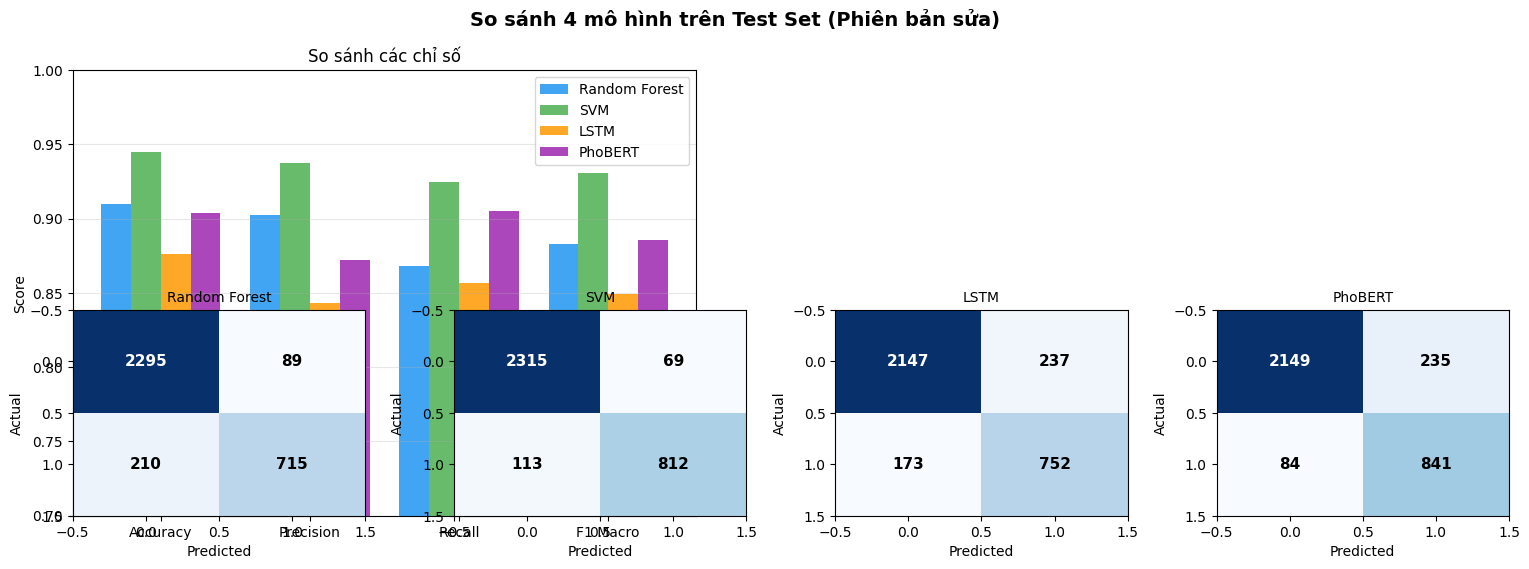


🏆 Mô hình tốt nhất: SVM (F1 Macro = 0.9307)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, precision_score, recall_score,
                             confusion_matrix)

# ── Bảng tổng hợp ──
models = ['Random Forest', 'SVM', 'LSTM', 'PhoBERT']
preds_list = [rf_preds_test, svm_preds_test, lstm_preds_test, bert_preds_test]

print("="*65)
print("🏆 BẢNG SO SÁNH 4 MÔ HÌNH TRÊN TEST SET ")
print("="*65)
print()
print(f"{'Mô hình':20s} {'Accuracy':>9s} {'Precision':>10s} {'Recall':>10s} {'F1 Macro':>10s} {'F1 Fake':>10s}")
print("─" * 65)

best_f1 = 0
best_model_name = ''

for name, preds in zip(models, preds_list):
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='macro')
    rec  = recall_score(y_test, preds, average='macro')
    f1   = f1_score(y_test, preds, average='macro')
    f1_fake = f1_score(y_test, preds, average=None)[1]  # F1 của class Fake

    star = ''
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        star = ' ⭐'

    print(f"  {name:18s} {acc:>9.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {f1_fake:>10.4f}{star}")

# ── Biểu đồ so sánh ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('So sánh 4 mô hình trên Test Set (Phiên bản sửa)', fontsize=14, fontweight='bold')

# Bar chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Macro']
x = np.arange(len(metrics_names))
width = 0.2
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, (name, preds) in enumerate(zip(models, preds_list)):
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='macro')
    rec  = recall_score(y_test, preds, average='macro')
    f1   = f1_score(y_test, preds, average='macro')
    values = [acc, prec, rec, f1]
    axes[0].bar(x + i * width, values, width, label=name, color=colors[i], alpha=0.85)

axes[0].set_xticks(x + 1.5 * width)
axes[0].set_xticklabels(metrics_names)
axes[0].set_ylim(0.7, 1.0)
axes[0].set_ylabel('Score')
axes[0].set_title('So sánh các chỉ số')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Confusion matrices
for i, (name, preds) in enumerate(zip(models, preds_list)):
    cm = confusion_matrix(y_test, preds)
    ax_sub = fig.add_subplot(2, 4, 5 + i)
    ax_sub.imshow(cm, cmap='Blues', aspect='auto')
    ax_sub.set_title(name, fontsize=10)
    ax_sub.set_xlabel('Predicted')
    ax_sub.set_ylabel('Actual')
    for r in range(2):
        for c in range(2):
            ax_sub.text(c, r, str(cm[r, c]), ha='center', va='center',
                       fontsize=11, fontweight='bold',
                       color='white' if cm[r, c] > cm.max()/2 else 'black')

axes[1].axis('off')  # Hide original subplot

plt.tight_layout()
plt.show()

print(f"\n🏆 Mô hình tốt nhất: {best_model_name} (F1 Macro = {best_f1:.4f})")


In [ ]:
import os
import pickle
import shutil
import torch
import pandas as pd # Import pandas here
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)

# Đường dẫn cơ sở trên Google Drive
DRIVE_DIR = '/content/drive/MyDrive/Final'
SAVE_DIR = os.path.join(DRIVE_DIR, 'results')
drive_models_dir = os.path.join(DRIVE_DIR, 'saved_models')

os.makedirs(SAVE_DIR, exist_ok=True)

# Lưu bảng so sánh
results_data = []
for name, preds in zip(models, preds_list):
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='macro')
    rec  = recall_score(y_test, preds, average='macro')
    f1   = f1_score(y_test, preds, average='macro')
    f1_fake = f1_score(y_test, preds, average=None)[1]
    results_data.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1_Macro': round(f1, 4),
        'F1_Fake': round(f1_fake, 4)
    })

results_df = pd.DataFrame(results_data)
results_df.to_csv(os.path.join(SAVE_DIR, 'compare_4_models_fixed_results.csv'), index=False)
print(f"✅ Đã lưu kết quả so sánh vào: {SAVE_DIR}/compare_4_models_fixed_results.csv")
print(results_df.to_string(index=False))

# ── Lưu các mô hình vào Google Drive ──
os.makedirs(drive_models_dir, exist_ok=True)
print(f"\n📦 Đang lưu các mô hình vào thư mục Google Drive: {drive_models_dir}")

# 1. Lưu TF-IDF Vectorizer
print("\n1️⃣  Lưu TF-IDF Vectorizer...")
with open(f'{drive_models_dir}/tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("   ✅ Đã lưu: tfidf.pkl")

# 2. Lưu Random Forest model
print("\n2️⃣  Lưu Random Forest model...")
with open(f'{drive_models_dir}/rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("   ✅ Đã lưu: rf_model.pkl")

# 3. Lưu SVM model
print("\n3️⃣  Lưu SVM model (Khuyến nghị cho web)...")
with open(f'{drive_models_dir}/svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
print("   ✅ Đã lưu: svm_model.pkl")

# 4. Lưu LSTM model (PyTorch)
print("\n4️⃣  Lưu LSTM model (PyTorch)...")
torch.save({
    'model_state_dict': lstm_model.state_dict(),
    'vocab_size': VOCAB_SIZE,
    'embed_dim': EMBED_DIM,
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
}, f'{drive_models_dir}/lstm_model.pth')
print("   ✅ Đã lưu: lstm_model.pth")

# 5. Lưu LSTM Vocabulary (thay vì tokenizer_lstm)
print("\n5️⃣  Lưu LSTM Vocabulary (word2idx)...")
with open(f'{drive_models_dir}/lstm_word2idx.pkl', 'wb') as f:
    pickle.dump(word2idx, f)
print("   ✅ Đã lưu: lstm_word2idx.pkl")

# 6. Sao chép PhoBERT model vào Drive
print("\n6️⃣  Sao chép PhoBERT model vào Drive...")
bert_model_drive = f'{drive_models_dir}/bert_model'
bert_tokenizer_drive = f'{drive_models_dir}/bert_tokenizer'

if os.path.exists(bert_model_drive):
    shutil.rmtree(bert_model_drive)
if os.path.exists(bert_tokenizer_drive):
    shutil.rmtree(bert_tokenizer_drive)

shutil.copytree(BERT_SAVE_PATH, bert_model_drive)
shutil.copytree(BERT_SAVE_PATH, bert_tokenizer_drive)
print("   ✅ Đã lưu PhoBERT vào thư mục: bert_model/ và bert_tokenizer/")


✅ Đã lưu kết quả so sánh vào: /content/drive/MyDrive/Final/results/compare_4_models_fixed_results.csv
        Model  Accuracy  Precision  Recall  F1_Macro  F1_Fake
Random Forest    0.9096     0.9027  0.8678    0.8830   0.8271
          SVM    0.9450     0.9376  0.9244    0.9307   0.8992
         LSTM    0.8761     0.8429  0.8568    0.8493   0.7858
      PhoBERT    0.9036     0.8720  0.9053    0.8857   0.8406

📦 Đang lưu các mô hình vào thư mục Google Drive: /content/drive/MyDrive/Final/saved_models

1️⃣  Lưu TF-IDF Vectorizer...
   ✅ Đã lưu: tfidf.pkl

2️⃣  Lưu Random Forest model...
   ✅ Đã lưu: rf_model.pkl

3️⃣  Lưu SVM model (Khuyến nghị cho web)...
   ✅ Đã lưu: svm_model.pkl

4️⃣  Lưu LSTM model (PyTorch)...
   ✅ Đã lưu: lstm_model.pth

5️⃣  Lưu LSTM Vocabulary (word2idx)...
   ✅ Đã lưu: lstm_word2idx.pkl

6️⃣  Sao chép PhoBERT model vào Drive...
   ✅ Đã lưu PhoBERT vào thư mục: bert_model/ và bert_tokenizer/
